# Titanic Data cleaning and EDA 
### Analystlab Africa Machine learning internship 
This notebook is for the week 1 of the analystlab africa machine learning internship.
in this notebook i will be performing data preprocessing and exploratory data analysis on the titanic dataset 
### **About the titanic dataset**
The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.
### Goal

To prepare datasets for machine learning by:
- Cleaning and transforming raw data
- Understanding feature distributions
- Identifying relationships between variables

### Task Breakdown
- Handle missing values and outliers
- Encode categorical variables
- Normalize/scale features
- Perform EDA (distributions, correlations)
- Create a function that cleans the dataset

## Phase 1: Importing the needed libriaries and dataset 

In [94]:
# importing needed libriaries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler

In [78]:
# importing the titanic dataset
titanic_df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

In [54]:
#checking the first 5 rows in the dataset 
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Sub-Phase 1.1: what do the columns in the data mean 
Columns:     Description 

Passenger ID: This is the id of each passengers in the dataset 

Survived:     This is the target column it shows if the passenger survived or not 

Pclass:       This is the Ticket class of the ship that is (1 = 1st, 2 = 2nd, 3 = 3rd)

Name:        This is the name of the passenger 

Sex:          This is the Gender of the passenger 

Age:        This is the Age of the passenger in year 

SibSp:        This is the No. of siblings / spouses aboard the Titanic

Parch:       This is the No. of parents / children aboard the Titanic

Ticket:       This is the Ticket number of passenger

Fare:         This is the Fare paid by each passenger 


## Phase 2: Exploratry Data Analysis 

In [5]:
#checking the shape of the dataset 
shape = titanic_df.shape 

print(f" There are {shape[0]} rows and {shape[1]} columns/features in the Titanic data ")

 There are 891 rows and 12 columns/features in the Titanic data 


In [6]:
# checking the statistical distribution of the data 
display(titanic_df.describe())

print("""
Insights:
- check out the Fare column see that the max is 512 which is different from the max of every other column so we will have to 
perfom normalization on that column.if the outliers lower performace but not removed for now \n
- also we will have to remove the Passenger id cause its just a count from 1 to 891
""")

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Insights:
- check out the Fare column see that the max is 512 which is different from the max of every other column so we will have to 
perfom normalization on that column.

- also we will have to remove the Passenger id cause its just a count from 1 to 891



In [28]:
#checking for duplicate column 
print(f" The duplicated rows are: {titanic_df.duplicated().sum()}")


 The duplicated rows are 0


In [7]:
# checking out the missing data in the dataset 
is_null_here = titanic_df.isna().sum() / len(titanic_df) * 100
is_nulldf = pd.DataFrame({"column": is_null_here.index, "Percent_missing":is_null_here.values})

display(is_nulldf)
print(f"Insights: \nwe will have to fill the age column and the Embarked column and maybe we will drop the cabin column")

,column,Percent_missing
0,PassengerId,0.000000
1,Survived,0.000000
2,Pclass,0.000000
3,Name,0.000000
4,Sex,0.000000
5,Age,19.865320
6,SibSp,0.000000
7,Parch,0.000000
8,Ticket,0.000000
9,Fare,0.000000


Insights: 
we will have to fill the age column and the Embarked column and maybe we will drop the cabin column


### Sub-Phase 2.1 statistical Relationships 
Checking the relationships between the colums 

insights: 

        In the passenger_ id to Fare and the Age to fare graph we see that we have a few outliers who have paid  500  we might remove this rows 

        
                


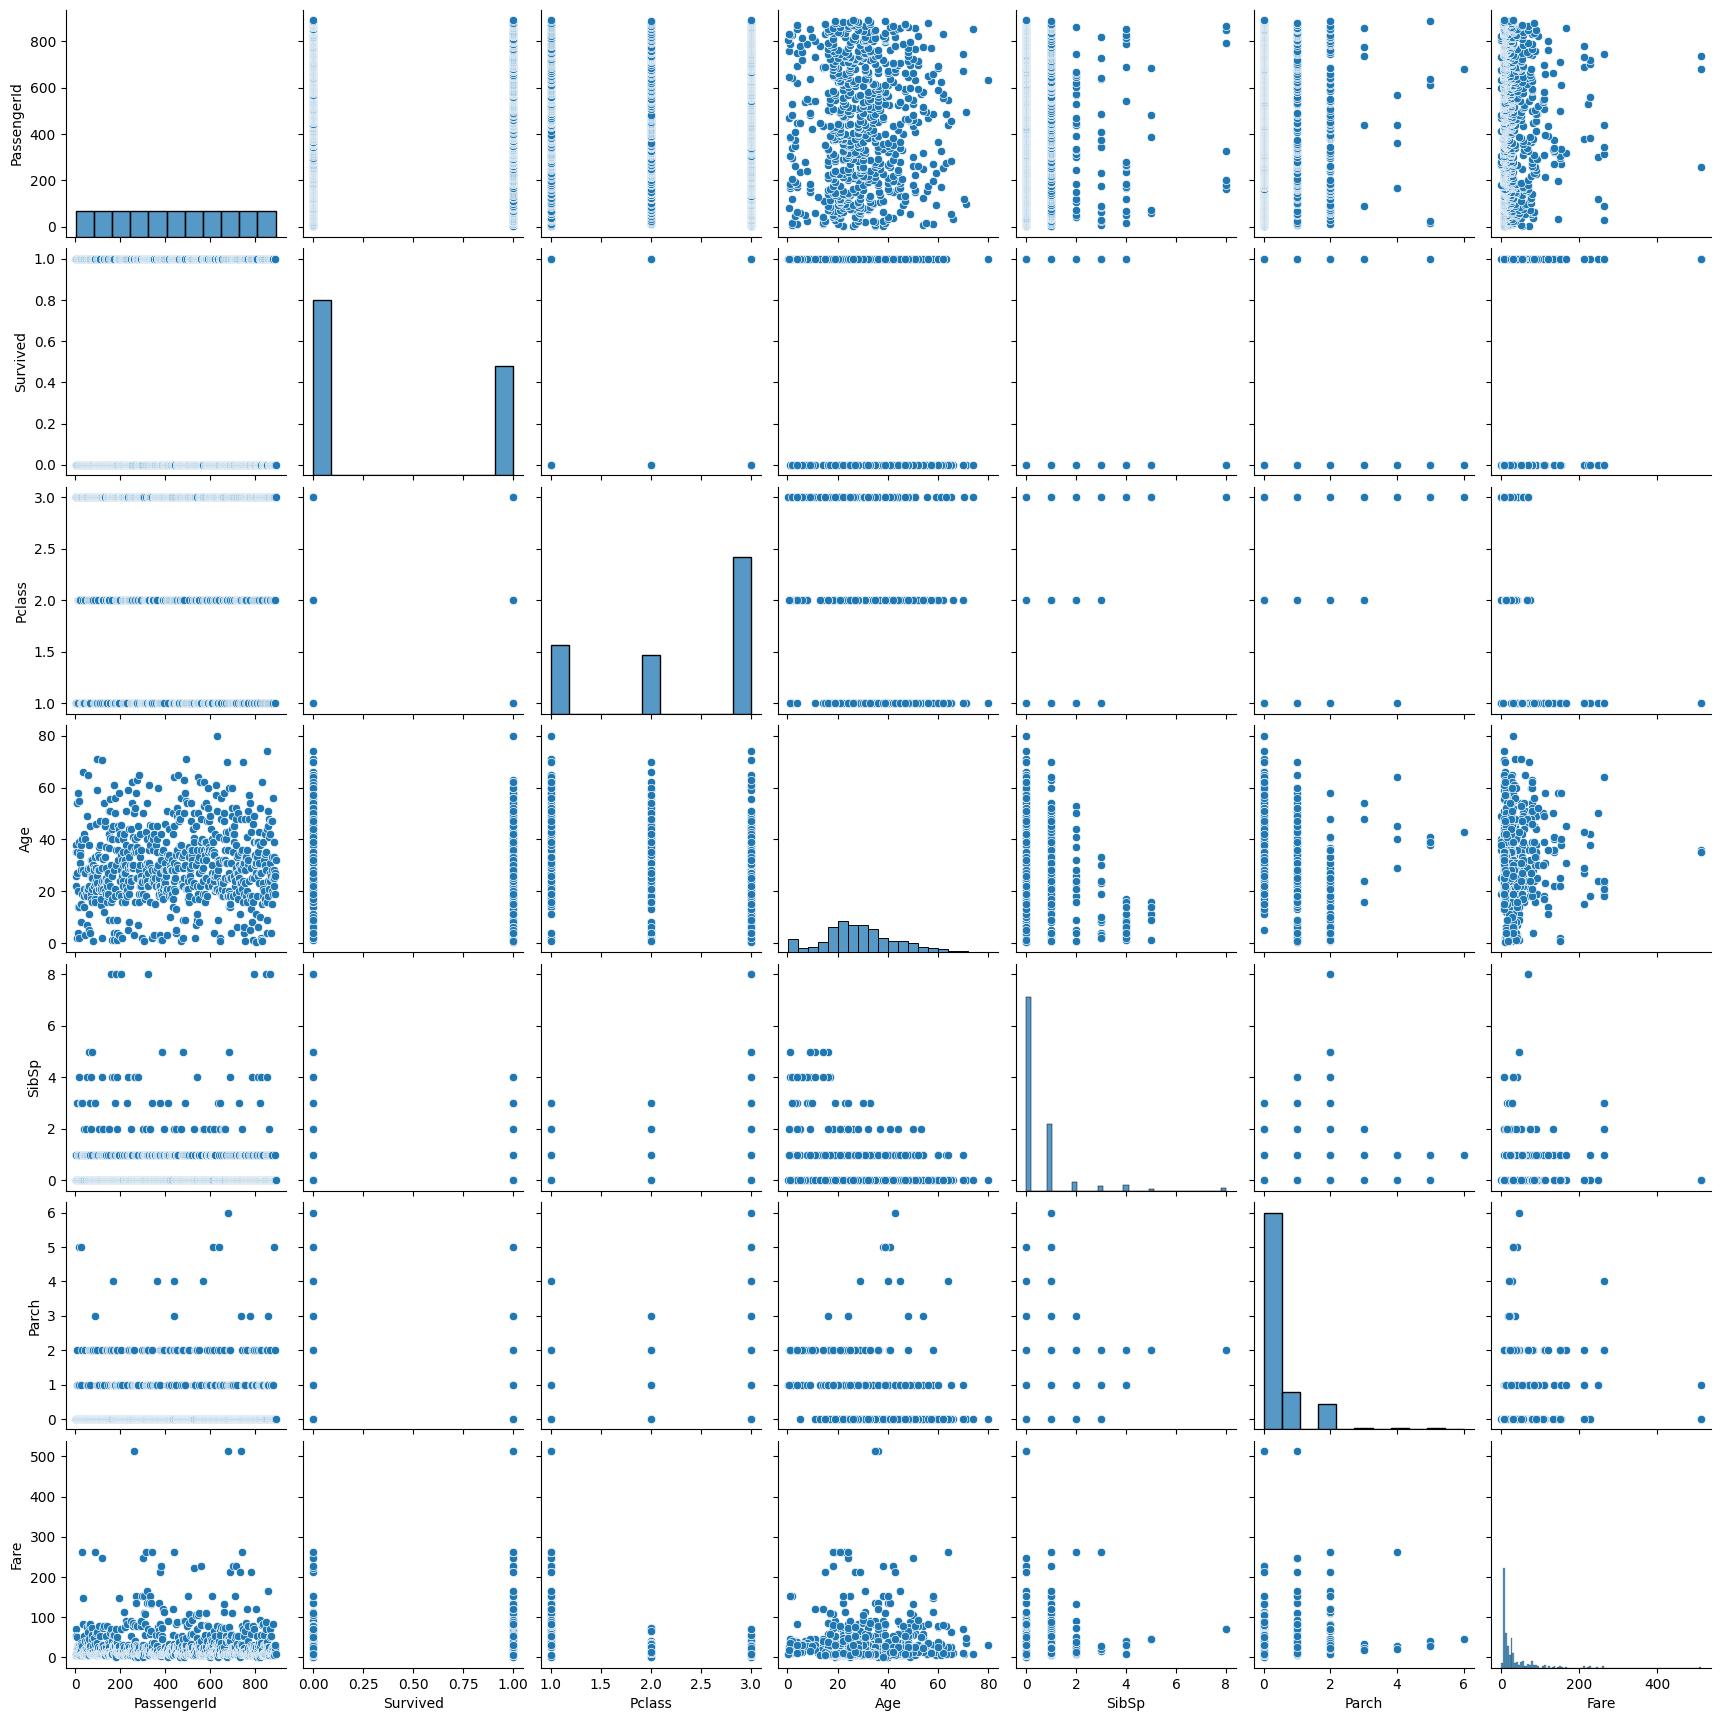

In [8]:
# firstly using seaborns pairplot to plot the overall relationships btwn columns 
sns.pairplot(titanic_df)

print("""insights: \n
        In the passenger_ id to Fare and the Age to fare graph we see that we have a few outliers who have paid  500  we might remove this rows \n
        
                """)

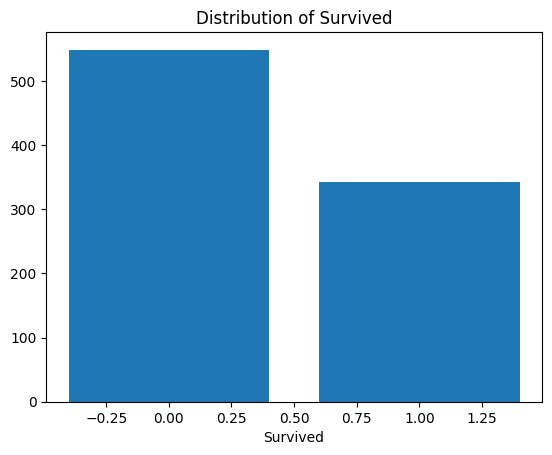

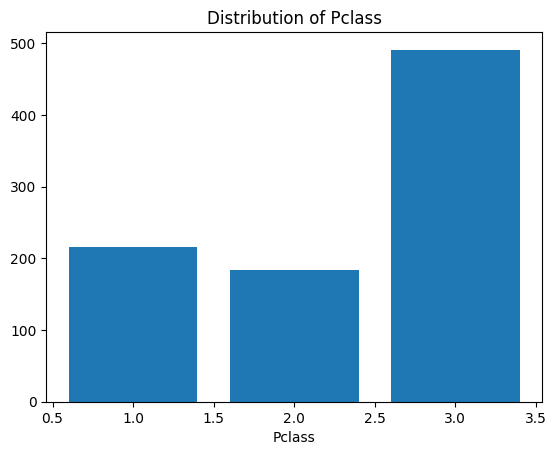

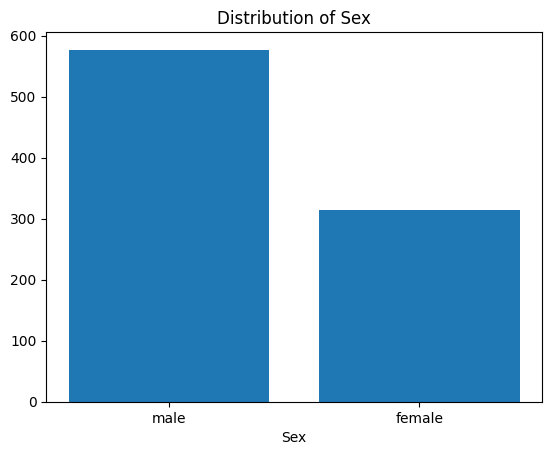

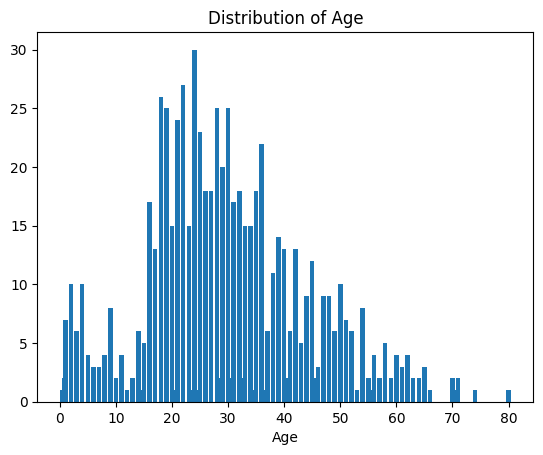

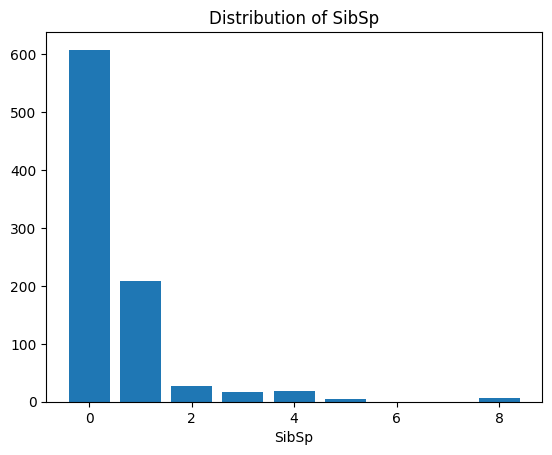

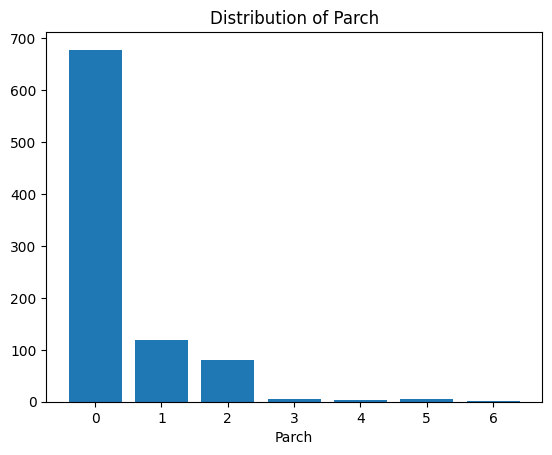

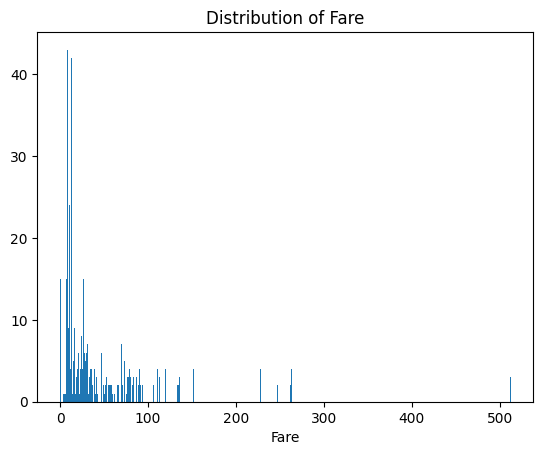

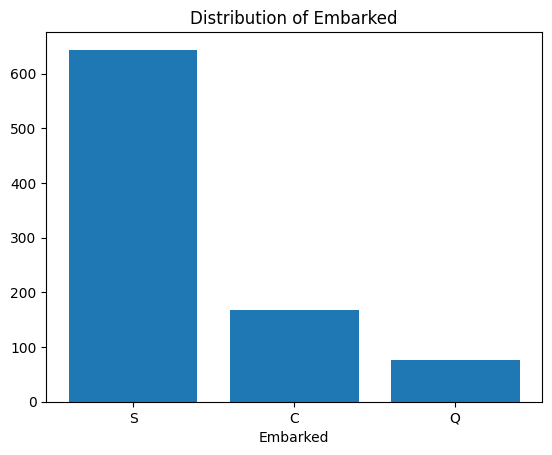


        Insights: 

        The Survived more people died than survived 

        In the Pclass there are  more people in 3rd class
        More males than females in the Sex column
        most passengers are from age 20 - 30 with some children being there also 
        most passengers dont have siblings, spouse , parents or children on the fight
        most passengers embaked from 'S'
    


In [9]:
# checking out the distribution of the data 
def plot_distribution(df, column_list):
    for column in column_list:
        df_val_counts = df[column].value_counts()
        plt.bar(df_val_counts.index, df_val_counts.values,align='center')
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.show()

column_list = [ "Survived", "Pclass", "Sex","Age", "SibSp", "Parch", "Fare", "Embarked" ]
plot_distribution(titanic_df, column_list)

print("""
        Insights: \n
        The Survived more people died than survived \n
        In the Pclass there are  more people in 3rd class
        More males than females in the Sex column
        most passengers are from age 20 - 30 with some children being there also 
        most passengers dont have siblings, spouse , parents or children on the fight
        most passengers embaked from 'S'
    """)

### Sub-Phrase 2.1: Columns Relationships with the target column('Survived')

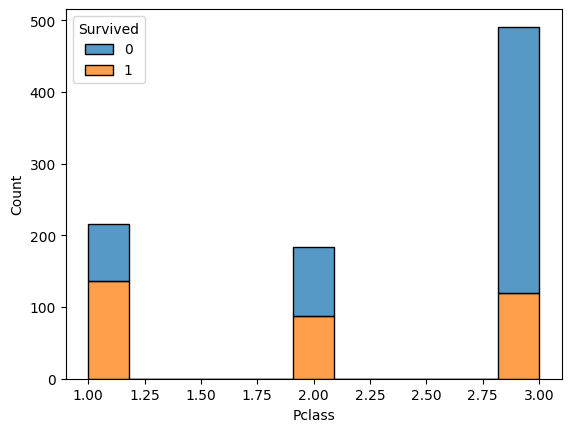

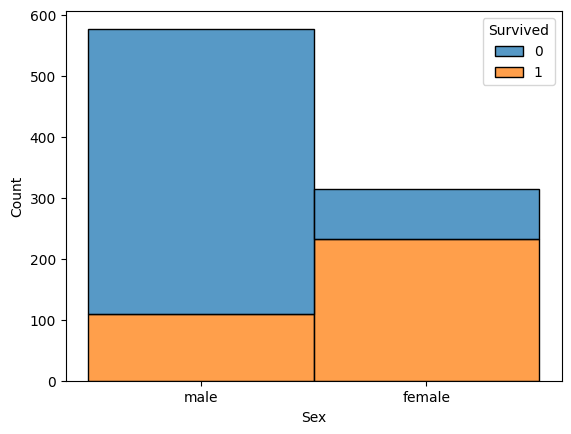

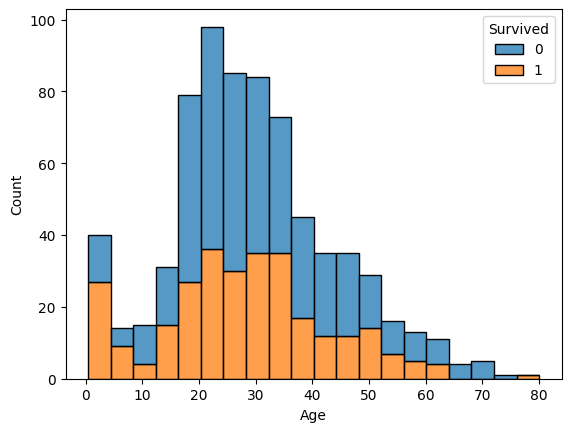

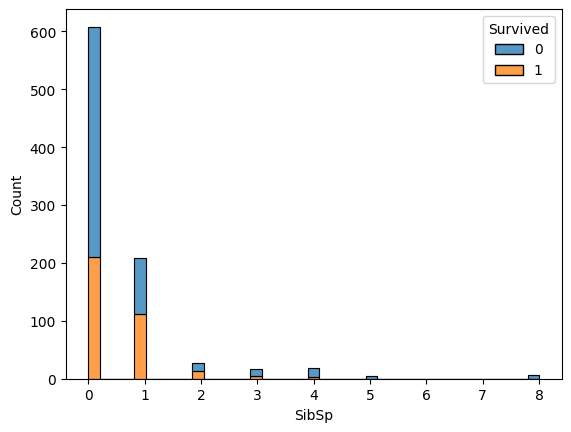

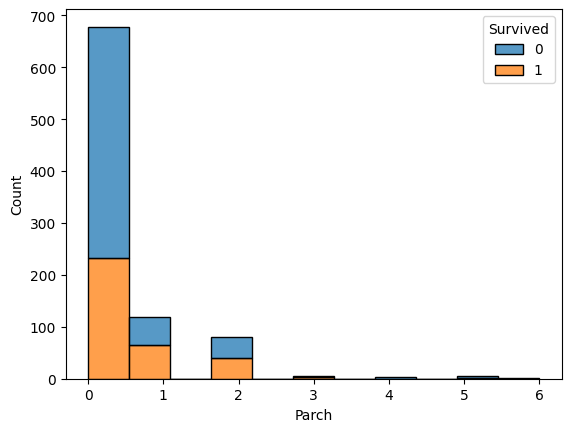

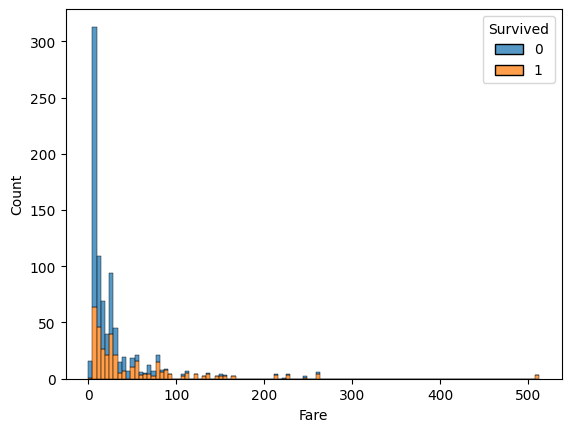

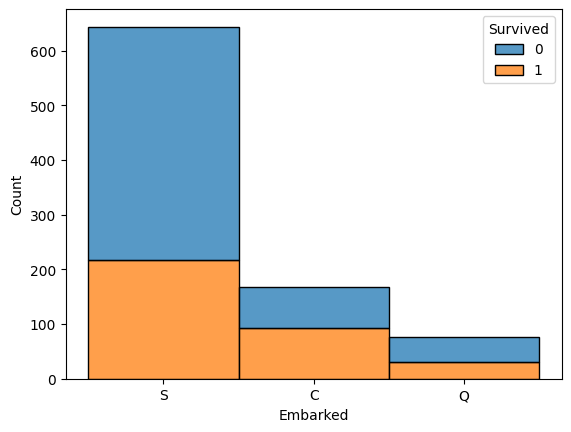

In [23]:
# checking out the distribution of the data 
def target_relationship_plot(df, column_list):
    for column in column_list:
        sns.histplot(titanic_df,x = column , hue = "Survived", multiple="stack")
        plt.title(f"Showing how Relationship Btween {column} and Survived")
        plt.show()

column_list = [ "Pclass", "Sex","Age", "SibSp", "Parch", "Fare", "Embarked" ]
target_relationship_plot(titanic_df, column_list)

print("""
        Insight:\n
        More passengers in Class 1 survived \n
        More Females Survived\n
        more siblings or spouse means death  \n
    """)

## Phase 3: Data Preprocessing 
using the insights from the previous chapters we then clean and preprocess the data 

In [88]:
## creating a function to clean and preprocess the data 
drop_column_list = ["PassengerId", "Name", "Sex", "Ticket", "Cabin"]
encode_colum_list = ["Embarked","title"]
def find_mean(df, column):
    """
    Finds the mean of the continous colum (int,float)
    """
    return df[column].mean()

def find_mode(df,column):
    """
    Finds the mode of the categorical column (object, str)
    """
    return df[column].mode()
    
    
def clean_df(df, drop_column_list: list ,encode_colum_list: list):
    """
    Cleans the dataframe that is imputed into it 
    Arguments:
    
    """
    # Feature Engineering side 
    # change the Sex column to only is female or not (0,1)
    print("Feature Engineering the Sex column")
    df["is_female"] = (df["Sex"] == "female").astype(int)
    print("Extracting titles from the  Name column")
    # extract the titles on the names of passengers 
    df['title'] = [ln.split()[1] for ln in df["Name"].values]
    df['title'] = [title if title in ['Mr.', 'Miss.', 'Mrs.', 'Master.', 'Dr.', 'Rev.','Baron.','Master.','Mlle.'] else 'Unknown' 
                   for title in df['title'].values ]

    # Preprocessing the data 
    # fill the missing data in the Age column
    print("filling the null values in Age column")
    mean_age = find_mean(df, "Age")
    df["Age"] = df["Age"].fillna(mean_age)
    # fill the missing data in the Embarked column
    print("filling the null values in Embarked column")
    mode_embarked = find_mode(df, "Embarked")
    df["Embarked"] = df["Embarked"].fillna(mode_embarked)
    # standardize the fare column
    # sdc = StandardScaler() # did not want to standardize the Fare column
    # df["Fare"] = sdc.fit_transform(df["Fare"])

    # droping the columns that are not in use 
    print("dropping the unwanted columns")
    df_droped = df.drop(columns = drop_column_list)
    #Encoding the categorical columns 
    print("Encoding the categorical columns")
    df_dummies = pd.get_dummies(df_droped, columns = encode_colum_list, drop_first = True,dtype=int)

    return df_dummies
    

In [89]:
# using the function to clean the data 
train = titanic_df.copy()

train_df = clean_df(train,drop_column_list,encode_colum_list)

Feature Engineering the Sex column
Extracting titles from the  Name column
filling the null values in Age column
filling the null values in Embarked column
dropping the unwanted columns
Encoding the categorical columns


In [93]:
# a peek into the clean dataset 
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Age            891 non-null    float64
 3   SibSp          891 non-null    int64  
 4   Parch          891 non-null    int64  
 5   Fare           891 non-null    float64
 6   is_female      891 non-null    int64  
 7   Embarked_Q     891 non-null    int64  
 8   Embarked_S     891 non-null    int64  
 9   title_Master.  891 non-null    int64  
 10  title_Miss.    891 non-null    int64  
 11  title_Mlle.    891 non-null    int64  
 12  title_Mr.      891 non-null    int64  
 13  title_Mrs.     891 non-null    int64  
 14  title_Rev.     891 non-null    int64  
 15  title_Unknown  891 non-null    int64  
dtypes: float64(2), int64(14)
memory usage: 111.5 KB


In [92]:
train_df.to_csv("cleaned_titanic.csv")

## Summary of findings 
- more females survived the titanic than males
- Tho the name column looks useless but we can extract the titles from names to form a titles column
- 